# Hyperparameter Tuning Results Analysis

**Objective:** Load and compare results from all 5 tuning .py files

**Input:** 5 CSV files with best hyperparameters per algorithm
- `catboost_best_params.csv`
- `gb_best_params.csv`
- `lightgbm_best_params.csv`
- `rf_best_params.csv`
- `xgb_best_params.csv`

**Output:** 
- Comparison visualizations
- Best hyperparameters documentation
- Ready for final training notebook

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print('✓ All libraries imported successfully')

✓ All libraries imported successfully


## 2. Load All Results CSVs

In [2]:
# Path to results 
data_dir = '/home/reu24mandaloju/projects/shell_ai_hack/data/'

# Load all results
catboost_df = pd.read_csv(f'{data_dir}catboost_best_params.csv')
gb_df = pd.read_csv(f'{data_dir}gb_best_params.csv')
lightgbm_df = pd.read_csv(f'{data_dir}lightgbm_best_params.csv')
rf_df = pd.read_csv(f'{data_dir}rf_best_params.csv')
xgb_df = pd.read_csv(f'{data_dir}xgb_best_params.csv')

print('✓ All CSV files loaded successfully')
print(f'  - CatBoost: {catboost_df.shape}')
print(f'  - Gradient Boosting: {gb_df.shape}')
print(f'  - LightGBM: {lightgbm_df.shape}')
print(f'  - Random Forest: {rf_df.shape}')
print(f'  - XGBoost: {xgb_df.shape}')

✓ All CSV files loaded successfully
  - CatBoost: (10, 6)
  - Gradient Boosting: (10, 7)
  - LightGBM: (10, 7)
  - Random Forest: (10, 7)
  - XGBoost: (10, 7)


## 3. Overall Performance Comparison

In [3]:
print('\n' + '='*80)
print('OVERALL PERFORMANCE COMPARISON')
print('='*80)

# Calculate average MAPE for each algorithm
algorithms = {
    'CatBoost': catboost_df,
    'Gradient Boosting': gb_df,
    'LightGBM': lightgbm_df,
    'Random Forest': rf_df,
    'XGBoost': xgb_df
}

overall_results = []

for algo_name, df in algorithms.items():
    avg_mape = df['Best_MAPE'].mean()
    std_mape = df['Best_MAPE'].std()
    min_mape = df['Best_MAPE'].min()
    max_mape = df['Best_MAPE'].max()
    
    overall_results.append({
        'Algorithm': algo_name,
        'Avg_MAPE': avg_mape,
        'Std_MAPE': std_mape,
        'Min_MAPE': min_mape,
        'Max_MAPE': max_mape
    })

overall_df = pd.DataFrame(overall_results).sort_values('Avg_MAPE')

print('\n' + overall_df.to_string(index=False))
print('\n✓ Best Algorithm (by Avg MAPE):', overall_df.iloc[0]['Algorithm'])


OVERALL PERFORMANCE COMPARISON

        Algorithm  Avg_MAPE  Std_MAPE  Min_MAPE  Max_MAPE
         CatBoost  0.787166  0.309364  0.199763  1.140153
          XGBoost  0.835002  0.308791  0.061400  1.103528
Gradient Boosting  0.921518  0.382574  0.040186  1.615442
         LightGBM  1.258283  0.646935  0.156334  2.218095
    Random Forest  1.334909  0.310785  0.779322  1.855437

✓ Best Algorithm (by Avg MAPE): CatBoost


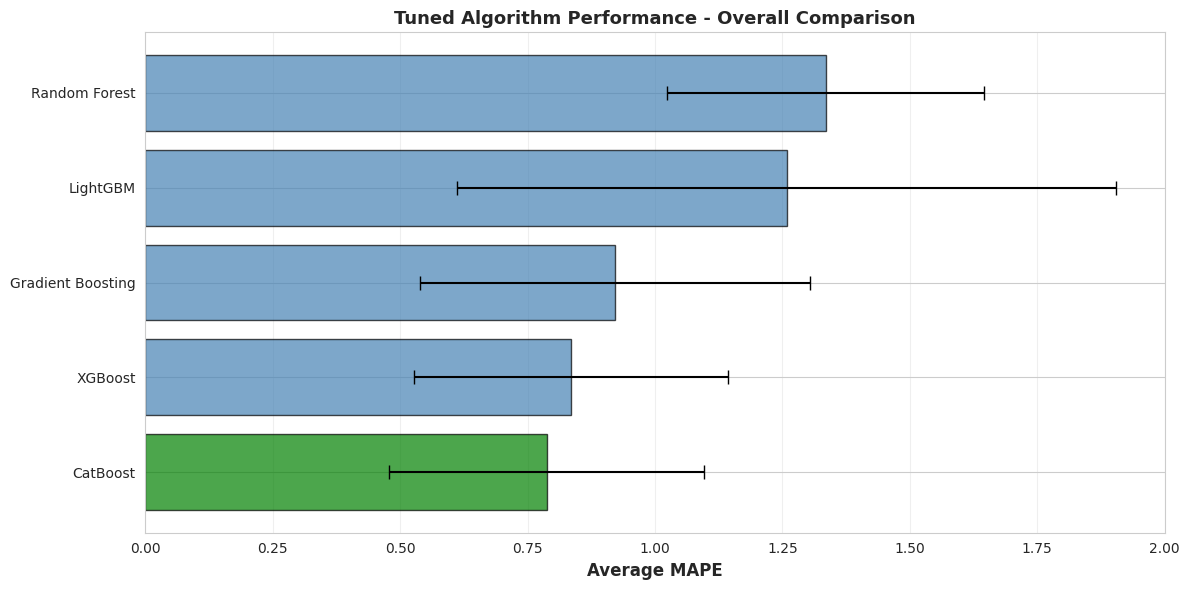

✓ Visualization complete


In [5]:
# Visualization: Overall Performance
fig, ax = plt.subplots(figsize=(12, 6))

algos = overall_df['Algorithm'].values
mapes = overall_df['Avg_MAPE'].values
stds = overall_df['Std_MAPE'].values

colors = ['green' if i == 0 else 'steelblue' for i in range(len(algos))]

ax.barh(algos, mapes, xerr=stds, capsize=5, color=colors, alpha=0.7, edgecolor='black')
ax.set_xlabel('Average MAPE', fontsize=12, fontweight='bold')
ax.set_title('Tuned Algorithm Performance - Overall Comparison', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print('✓ Visualization complete')

## 4. Per-Target Performance Analysis

In [4]:
print('\n' + '='*80)
print('PER-TARGET PERFORMANCE')
print('='*80)

# Create comparison dataframe for each target
target_cols = catboost_df['Target'].unique()

per_target = []

for target in target_cols:
    row = {'Target': target}
    for algo_name, df in algorithms.items():
        mape = df[df['Target'] == target]['Best_MAPE'].values[0]
        row[algo_name] = mape
    per_target.append(row)

per_target_df = pd.DataFrame(per_target)

print('\n' + per_target_df.to_string(index=False))

# Find best algorithm per target
print('\n' + '-'*80)
print('Best Algorithm Per Target:')
print('-'*80)
for target in target_cols:
    row = per_target_df[per_target_df['Target'] == target].iloc[0]
    best_algo = row[1:].idxmin()
    best_mape = row[1:].min()
    print(f'  {target:15s}: {best_algo:20s} (MAPE: {best_mape:.4f})')


PER-TARGET PERFORMANCE

         Target  CatBoost  Gradient Boosting  LightGBM  Random Forest  XGBoost
 BlendProperty1  1.078682           1.031780  1.885031       1.700618 0.955250
 BlendProperty2  0.619127           0.818737  0.919289       1.178076 0.734577
 BlendProperty3  1.074068           1.012186  1.328308       1.293383 1.085524
 BlendProperty4  0.609093           0.939831  0.967404       1.282645 0.822364
 BlendProperty5  0.199763           0.040186  0.156334       0.779322 0.061400
 BlendProperty6  0.652947           0.823390  0.939017       1.248780 0.792501
 BlendProperty7  1.140153           1.615442  2.218095       1.610270 1.103528
 BlendProperty8  1.003799           0.979689       NaN       1.139571 1.057552
 BlendProperty9  0.966447           1.042357  1.922265       1.260991 1.021199
BlendProperty10  0.527578           0.911583  0.988804       1.855437 0.716125

--------------------------------------------------------------------------------
Best Algorithm Per Targe

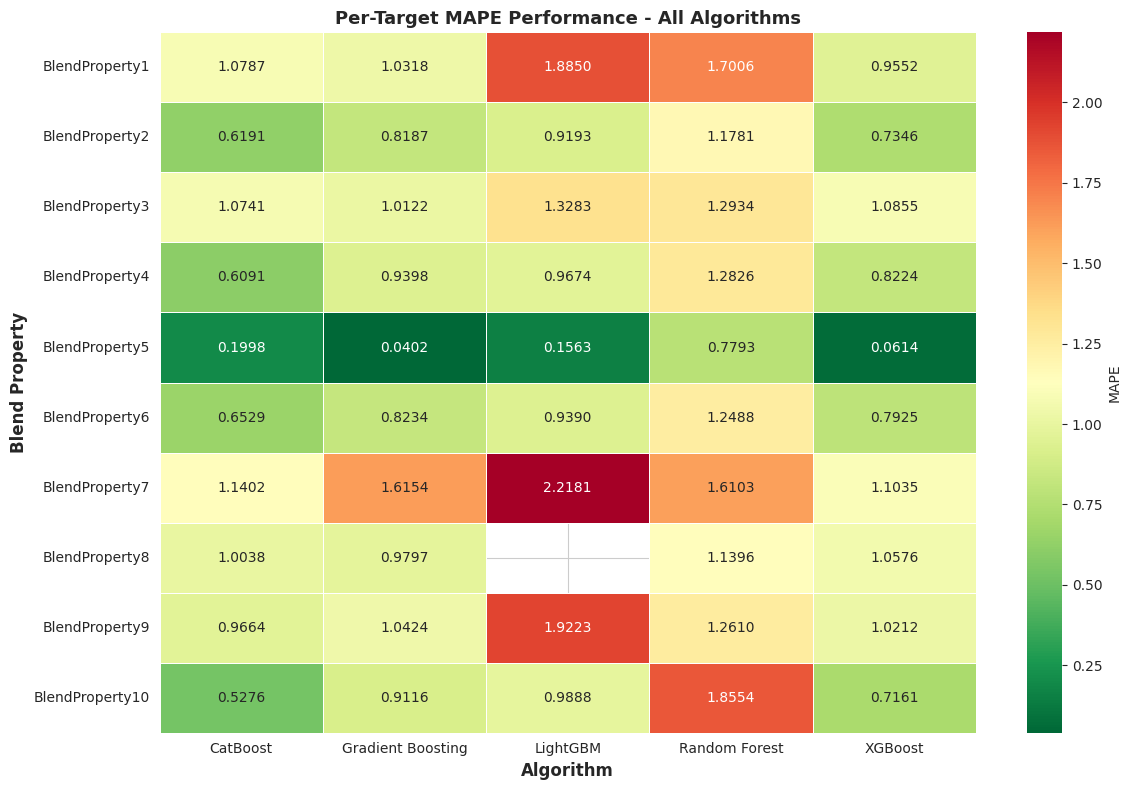

✓ Heatmap complete


In [5]:
# Heatmap: Per-Target Performance
fig, ax = plt.subplots(figsize=(12, 8))

heatmap_data = per_target_df.set_index('Target').iloc[:, :5]

sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='RdYlGn_r', 
            cbar_kws={'label': 'MAPE'}, ax=ax, linewidths=0.5)

ax.set_title('Per-Target MAPE Performance - All Algorithms', fontsize=13, fontweight='bold')
ax.set_xlabel('Algorithm', fontsize=12, fontweight='bold')
ax.set_ylabel('Blend Property', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print('✓ Heatmap complete')

## 5. Best Hyperparameters Documentation

In [6]:
print('\n' + '='*80)
print('BEST HYPERPARAMETERS FOR EACH ALGORITHM')
print('='*80)

for algo_name, df in algorithms.items():
    print(f'\n{algo_name}:')
    print(f'  Tuned MAPE: {df["Best_MAPE"].mean():.4f}')
    print(f'  Best hyperparameters per target:')
    
    for _, row in df.iterrows():
        target = row['Target']
        mape = row['Best_MAPE']
        print(f'\n    {target}:')
        print(f'      MAPE: {mape:.4f}')
        
        # Get hyperparameters (all columns except Target and Best_MAPE)
        params = row.drop(['Target', 'Best_MAPE']).to_dict()
        for param_name, param_value in params.items():
            print(f'      {param_name}: {param_value}')


BEST HYPERPARAMETERS FOR EACH ALGORITHM

CatBoost:
  Tuned MAPE: 0.7872
  Best hyperparameters per target:

    BlendProperty1:
      MAPE: 1.0787
      depth: 8
      iterations: 200
      l2_leaf_reg: 3
      learning_rate: 0.1

    BlendProperty2:
      MAPE: 0.6191
      depth: 6
      iterations: 200
      l2_leaf_reg: 5
      learning_rate: 0.1

    BlendProperty3:
      MAPE: 1.0741
      depth: 6
      iterations: 200
      l2_leaf_reg: 1
      learning_rate: 0.1

    BlendProperty4:
      MAPE: 0.6091
      depth: 4
      iterations: 200
      l2_leaf_reg: 3
      learning_rate: 0.1

    BlendProperty5:
      MAPE: 0.1998
      depth: 6
      iterations: 200
      l2_leaf_reg: 1
      learning_rate: 0.03

    BlendProperty6:
      MAPE: 0.6529
      depth: 4
      iterations: 200
      l2_leaf_reg: 5
      learning_rate: 0.1

    BlendProperty7:
      MAPE: 1.1402
      depth: 8
      iterations: 200
      l2_leaf_reg: 3
      learning_rate: 0.2

    BlendProperty8:
      MAP

## 6. Improvement Summary

In [7]:
print('\n' + '='*80)
print('TUNING SUMMARY & INSIGHTS')
print('='*80)

# Baseline from 03_model_experiments
baseline_results = {
    'Gradient Boosting': 1.1872,
    'CatBoost': 1.2604,
    'LightGBM': 1.3136,
    'XGBoost': 1.3327,
    'Random Forest': 1.9521
}

print('\nBaseline (from 03_model_experiments) vs Tuned:')
print(f'\n{"Algorithm":<25} {"Baseline":<12} {"Tuned":<12} {"Improvement":<15}')
print('-'*80)

for algo_name, baseline_mape in baseline_results.items():
    tuned_mape = overall_df[overall_df['Algorithm'] == algo_name]['Avg_MAPE'].values[0]
    improvement = baseline_mape - tuned_mape
    improvement_pct = (improvement / baseline_mape) * 100
    
    status = '✓ Improved' if improvement > 0 else '⚠️ Worse' if improvement < 0 else '= No change'
    print(f'{algo_name:<25} {baseline_mape:<12.4f} {tuned_mape:<12.4f} {improvement:+.4f} ({improvement_pct:+.2f}%) {status}')


TUNING SUMMARY & INSIGHTS

Baseline (from 03_model_experiments) vs Tuned:

Algorithm                 Baseline     Tuned        Improvement    
--------------------------------------------------------------------------------
Gradient Boosting         1.1872       0.9215       +0.2657 (+22.38%) ✓ Improved
CatBoost                  1.2604       0.7872       +0.4732 (+37.55%) ✓ Improved
LightGBM                  1.3136       1.2583       +0.0553 (+4.21%) ✓ Improved
XGBoost                   1.3327       0.8350       +0.4977 (+37.35%) ✓ Improved
Random Forest             1.9521       1.3349       +0.6172 (+31.62%) ✓ Improved


## 7. Export Best Parameters

In [ ]:
# Save combined results for reference
output_dir = '/home/reu24mandaloju/projects/shell_ai_hack/data/'
 
# Save overall comparison
overall_df.to_csv(f'{output_dir}tuning_overall_comparison.csv', index=False)
print(f'✓ Saved overall comparison to: {output_dir}tuning_overall_comparison.csv')

# Save per-target comparison
per_target_df.to_csv(f'{output_dir}tuning_per_target_comparison.csv', index=False)
print(f'✓ Saved per-target comparison to: {output_dir}tuning_per_target_comparison.csv')

print('\n✅ All tuning results compiled and exported')

## 8. Final Recommendations

In [8]:
print('\n' + '='*80)
print('RECOMMENDATIONS FOR FINAL TRAINING')
print('='*80)

best_overall = overall_df.iloc[0]
best_algo_name = best_overall['Algorithm']
best_algo_mape = best_overall['Avg_MAPE']

print(f'\n✅ PRIMARY ALGORITHM: {best_algo_name}')
print(f'   Average Tuned MAPE: {best_algo_mape:.4f}')
print(f'   Use this for main predictions')

top_3 = overall_df.head(3)
print(f'\n✅ TOP 3 ALGORITHMS (for ensemble):')
for i, (idx, row) in enumerate(top_3.iterrows(), 1):
    print(f'   {i}. {row["Algorithm"]:20s} - MAPE: {row["Avg_MAPE"]:.4f}')

print(f'\n📋 NEXT NOTEBOOK: 05_final_training_and_predictions.ipynb')
print(f'   - Use best hyperparameters from above')
print(f'   - Train on full training data (2000 samples)')
print(f'   - Make predictions on test set')

print(f'\n📋 THEN: 06_ensemble_methods.ipynb')
print(f'   - Combine top 3 algorithms')
print(f'   - Find optimal ensemble weights')
print(f'   - Generate final predictions')

print('\n' + '='*80)


RECOMMENDATIONS FOR FINAL TRAINING

✅ PRIMARY ALGORITHM: CatBoost
   Average Tuned MAPE: 0.7872
   Use this for main predictions

✅ TOP 3 ALGORITHMS (for ensemble):
   1. CatBoost             - MAPE: 0.7872
   2. XGBoost              - MAPE: 0.8350
   3. Gradient Boosting    - MAPE: 0.9215

📋 NEXT NOTEBOOK: 05_final_training_and_predictions.ipynb
   - Use best hyperparameters from above
   - Train on full training data (2000 samples)
   - Make predictions on test set

📋 THEN: 06_ensemble_methods.ipynb
   - Combine top 3 algorithms
   - Find optimal ensemble weights
   - Generate final predictions

